#  Regresion: Predicción de ventas en una tienda de videojuegos
1. Preparación de Datos
2. División de los datos
3. Aprendizaje del Modelo
4. Evaluación del Modelo: MSE, RMSE, MAE, MAPE
5. Guardamos el modelo

In [275]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos


In [306]:
#Cargamos los datos
data = pd.read_csv("videojuegos.csv")
data.head()

In [277]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   videojuego                 152 non-null    object
 1   Edad                       152 non-null    int64 
 2   Sexo                       152 non-null    object
 3   Plataforma                 152 non-null    object
 4   Consumidor_habitual        152 non-null    bool  
 5   Presupuesto para invertir  152 non-null    int64 
dtypes: bool(1), int64(2), object(3)
memory usage: 6.2+ KB


In [278]:
categories = ["videojuego","Sexo","Plataforma"]

for category in categories:
  data[category] = data[category].astype("category")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   videojuego                 152 non-null    category
 1   Edad                       152 non-null    int64   
 2   Sexo                       152 non-null    category
 3   Plataforma                 152 non-null    category
 4   Consumidor_habitual        152 non-null    bool    
 5   Presupuesto para invertir  152 non-null    int64   
dtypes: bool(1), category(3), int64(2)
memory usage: 3.8 KB


<Axes: >

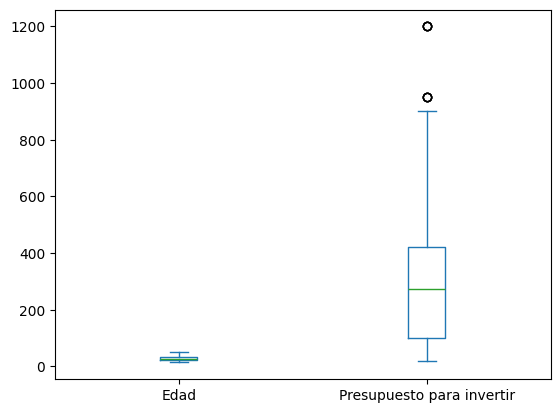

In [279]:
data.plot(kind="box")

videojuego


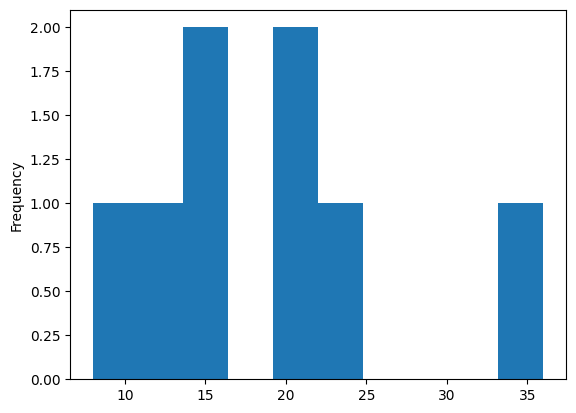

Sexo


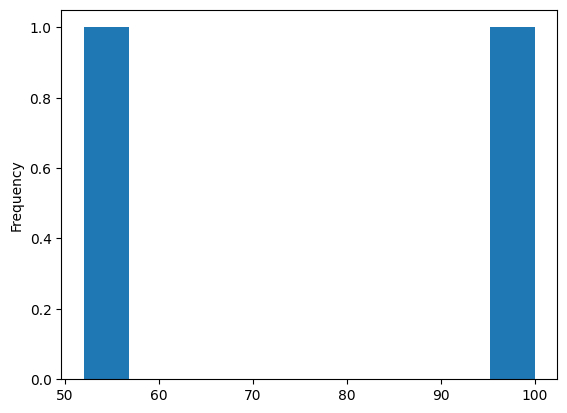

Plataforma


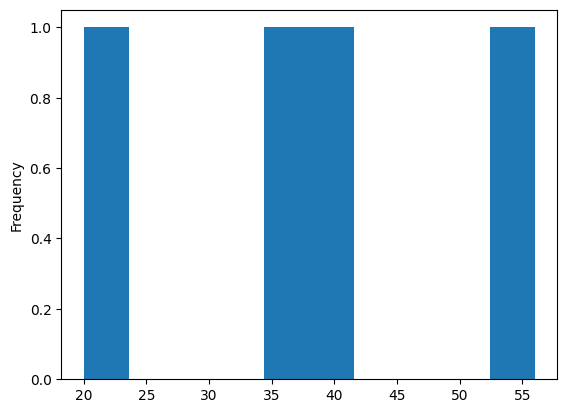

In [280]:
for category in categories:
  print(category)
  data[category].value_counts().plot(kind="hist")
  plt.show()

In [281]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,152.0,28.000000,9.990724,14.0,21.0,26.0,34.0,52.0
Presupuesto para invertir,152.0,343.289474,291.945464,20.0,100.0,275.0,420.0,1200.0


In [282]:
#Creamos variables dummy para convertir  las categorías a números
data = pd.get_dummies(data, columns=['videojuego', 'Plataforma'], drop_first=False, dtype=int)
data = pd.get_dummies(data, columns=['Sexo', 'Consumidor_habitual'], drop_first=True, dtype=int)
data.head()

,Edad,Presupuesto para invertir,videojuego_'Battlefield',videojuego_'Crysis',videojuego_'Dead Space',videojuego_'F1',videojuego_'Fifa',videojuego_'KOA: Reckoning',videojuego_'Mass Effect',videojuego_'Sim City',Plataforma_'Play Station',Plataforma_'Xbox',Plataforma_Otros,Plataforma_PC,Sexo_Mujer,Consumidor_habitual_True
0,29,200,0,0,0,0,0,0,1,0,0,0,0,1,1,1
1,27,600,0,0,0,0,0,0,0,1,0,0,1,0,1,1
2,22,200,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,28,370,1,0,0,0,0,0,0,0,0,1,0,0,1,1
4,30,100,0,0,0,0,0,1,0,0,0,0,0,1,1,1


**No hay Laber Encoded -> Variable objetivo ya es numerica**

# 2. División 70-30


<Axes: >

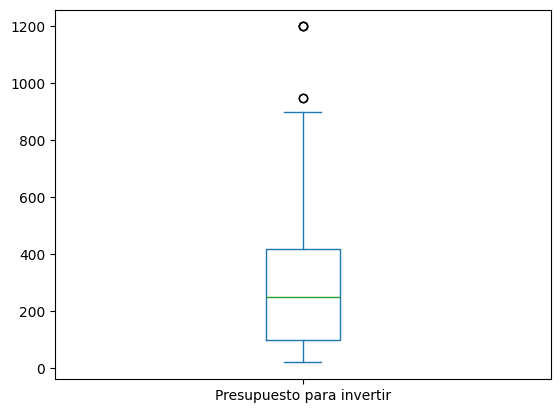

In [283]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("Presupuesto para invertir", axis = 1) # Variables predictoras
Y = data['Presupuesto para invertir'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=None) #En prediccion el muestreo es linear, no tiene categorias por lo tanto no tiene clases a las que le debamos preservar las proporciones
Y_train.plot(kind='box')

<Axes: ylabel='Frequency'>

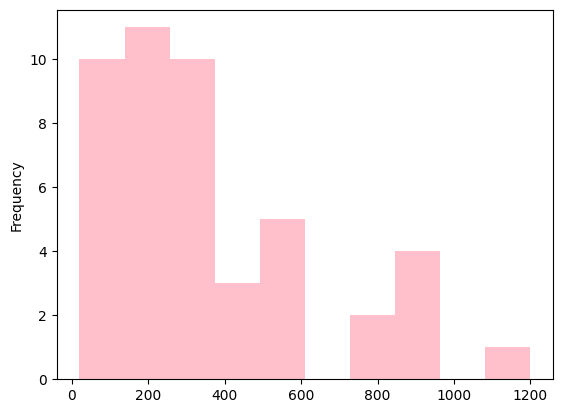

In [284]:
# Variable objetivo del 30% - hist
Y_test.plot(kind="hist", color="pink")

# 3. Aprendizaje  70% y Evaluación 30%

In [285]:
#Dataframe para comparar los resultados
medidas= pd.DataFrame(index=['mse','rmse','mae','mape','max'])

# Arbol de Regresión
-No se normaliza

In [286]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeRegressor

model_Tree = DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=2, max_depth=None)
model_Tree.fit(X_train, Y_train)#70% entrenamiento

DecisionTreeRegressor(min_samples_leaf=2)

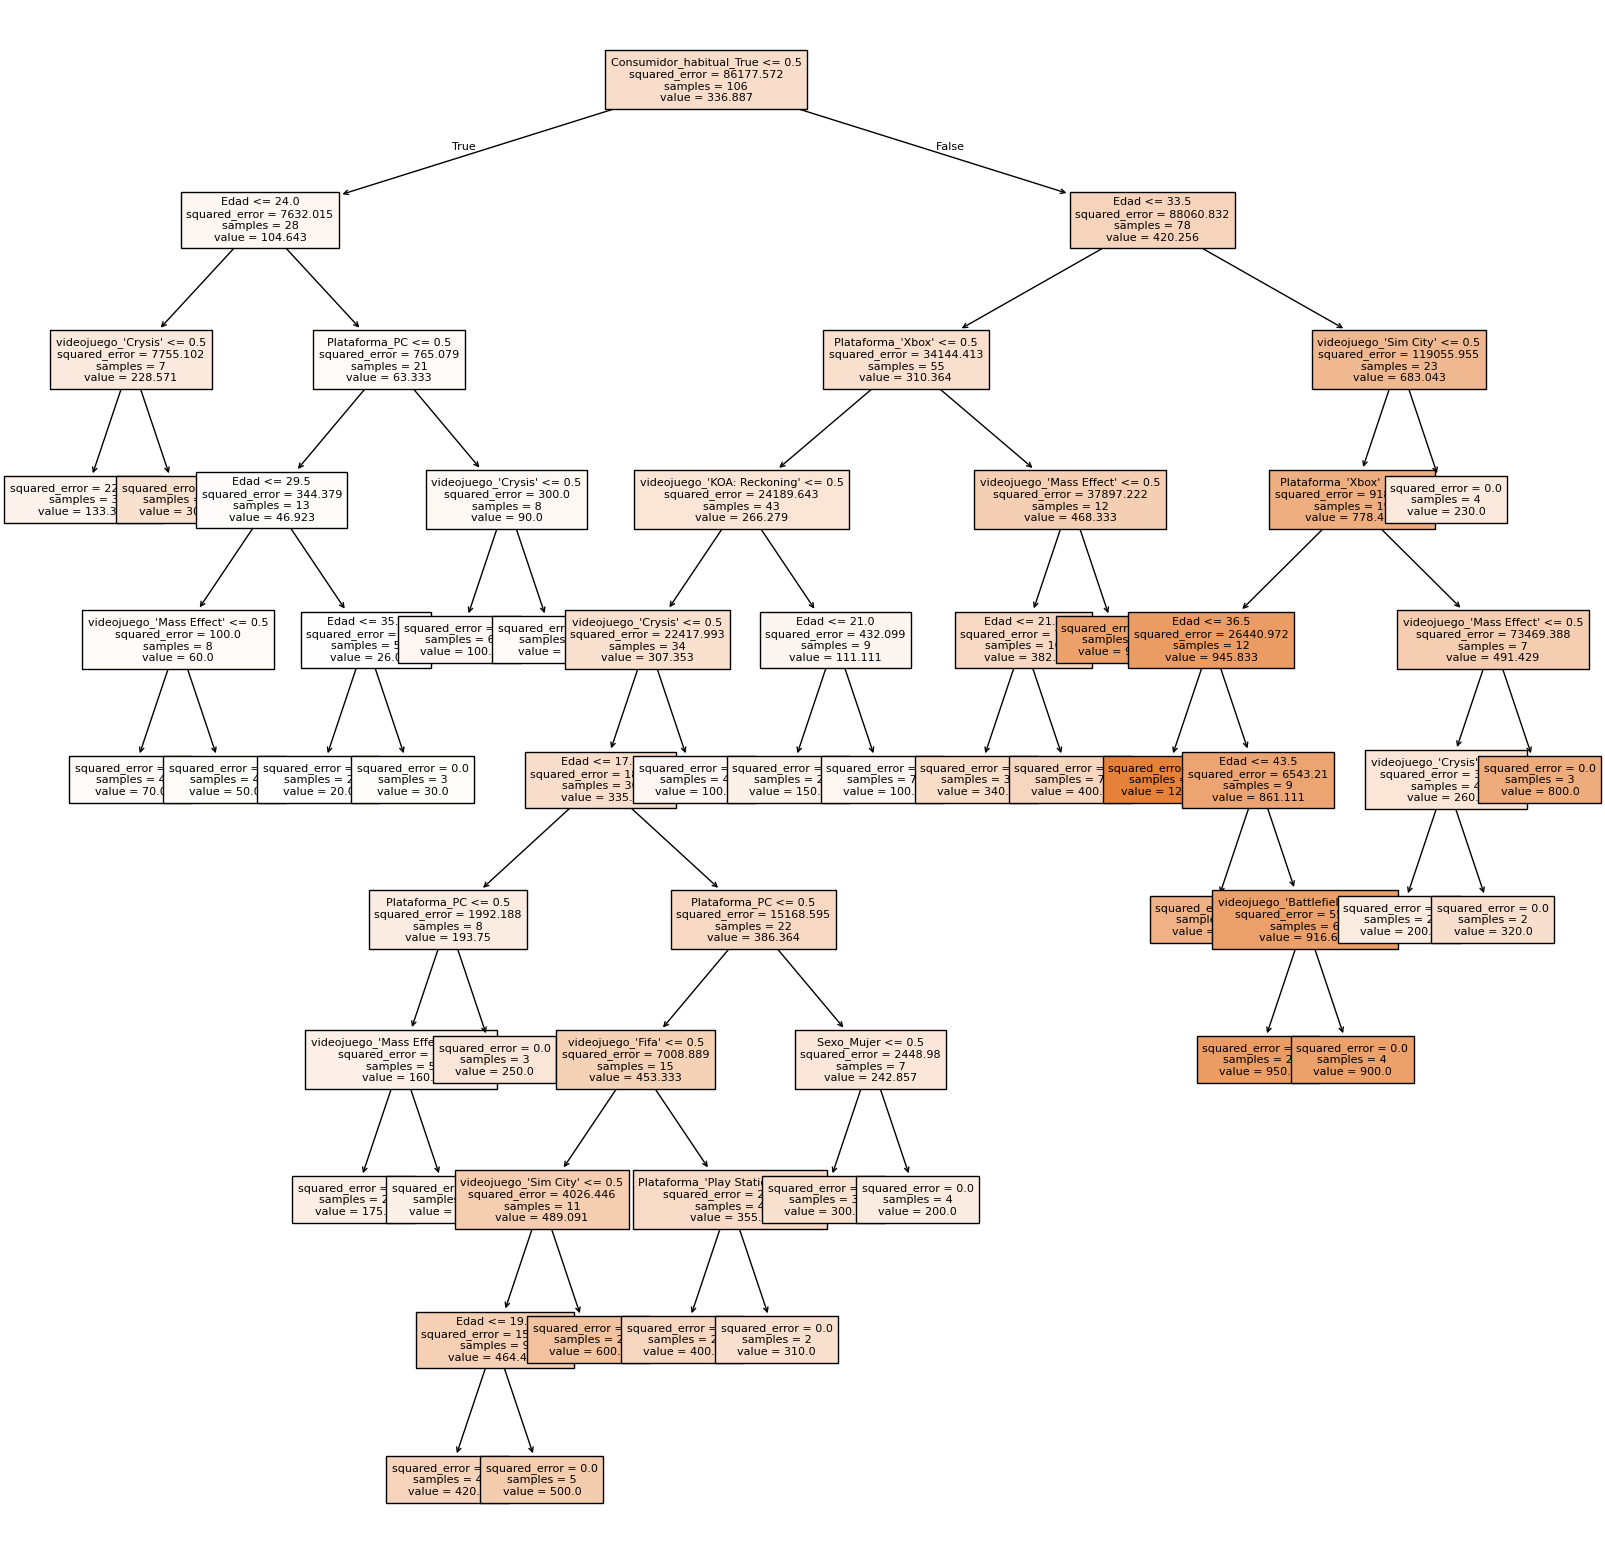

In [287]:
#Graficar el árbol
from sklearn.tree import plot_tree
nombres_variables=X_train.columns.values
plt.figure(figsize=(20,20))
plot_tree(model_Tree, feature_names=nombres_variables, filled=True,fontsize=8)
plt.show()

In [288]:
from sklearn import metrics
Y_pred = model_Tree.predict(X_test) #30%

#Medidas de evaluación en regresión
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred) # Verificar si la variable objetivo tiene ceros
max=metrics.max_error(Y_test,Y_pred)
medidas['Arbol']=[mse, rmse, mae, mape,max]
medidas.T

,mse,rmse,mae,mape,max
Arbol,416.425121,20.406497,8.405797,0.043282,66.666667


/tmp/ipykernel_6403/2783684465.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


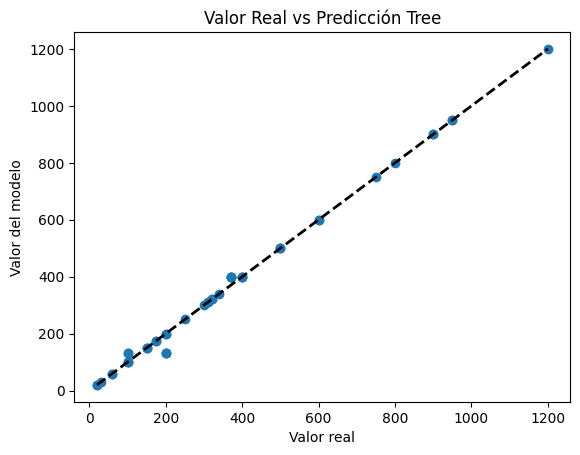

In [289]:
#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Tree')
plt.show() # Mostrar la grafica luego de que ya se definio todos los elementos

# KNN para Regresión
* Normalización de las var numéricas

In [290]:
#Normalizacion de las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

variables_numericas=['Edad']

#Ajuste de los parametros sobre 100% de los datos (data): max - min
min_max_scaler.fit(data[variables_numericas])

#Se aplica la normalización a 70%  y 30%
X_train[variables_numericas]= min_max_scaler.transform(X_train[variables_numericas]) #70%
X_test[variables_numericas]= min_max_scaler.transform(X_test[variables_numericas]) #30%
X_train.head()

,Edad,videojuego_'Battlefield',videojuego_'Crysis',videojuego_'Dead Space',videojuego_'F1',videojuego_'Fifa',videojuego_'KOA: Reckoning',videojuego_'Mass Effect',videojuego_'Sim City',Plataforma_'Play Station',Plataforma_'Xbox',Plataforma_Otros,Plataforma_PC,Sexo_Mujer,Consumidor_habitual_True
95,0.315789,1,0,0,0,0,0,0,0,0,0,1,0,0,0
47,0.000000,0,0,0,0,1,0,0,0,1,0,0,0,0,1
12,0.605263,0,0,0,0,0,0,0,1,0,0,0,1,1,0
149,0.552632,0,0,0,0,0,0,1,0,0,1,0,0,1,1
67,0.184211,0,0,0,1,0,0,0,0,1,0,0,0,1,1


In [291]:
X_test.head()

,Edad,videojuego_'Battlefield',videojuego_'Crysis',videojuego_'Dead Space',videojuego_'F1',videojuego_'Fifa',videojuego_'KOA: Reckoning',videojuego_'Mass Effect',videojuego_'Sim City',Plataforma_'Play Station',Plataforma_'Xbox',Plataforma_Otros,Plataforma_PC,Sexo_Mujer,Consumidor_habitual_True
110,0.894737,0,0,0,0,0,0,1,0,1,0,0,0,0,1
89,0.289474,0,0,0,0,1,0,0,0,1,0,0,0,0,1
108,0.026316,0,0,0,0,1,0,0,0,0,0,0,1,0,0
40,0.210526,0,0,1,0,0,0,0,0,0,1,0,0,0,0
122,0.184211,0,0,0,0,0,0,1,0,1,0,0,0,0,1


In [292]:
from sklearn.neighbors import  KNeighborsRegressor
model_Knn = KNeighborsRegressor(n_neighbors=1, metric='euclidean') #minkowski
model_Knn.fit(X_train, Y_train) #70%

KNeighborsRegressor(metric='euclidean', n_neighbors=1)

           Arbol        Knn
mse   416.425121  78.260870
rmse   20.406497   8.846517
mae     8.405797   2.608696
mape    0.043282   0.007051
max    66.666667  30.000000


/tmp/ipykernel_6403/73678959.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


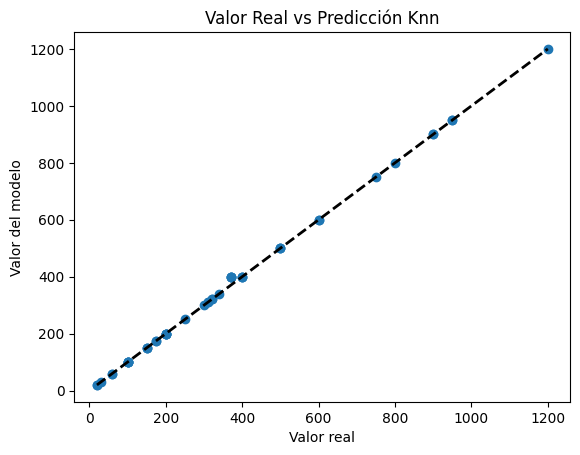

In [293]:
#Evaluación de KNN
from sklearn import metrics

Y_pred = model_Knn.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['Knn']=[mse, rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Knn')
plt.show()

# Red Neuronal para Regresión
- Normalizar

In [294]:
X_train.head()

,Edad,videojuego_'Battlefield',videojuego_'Crysis',videojuego_'Dead Space',videojuego_'F1',videojuego_'Fifa',videojuego_'KOA: Reckoning',videojuego_'Mass Effect',videojuego_'Sim City',Plataforma_'Play Station',Plataforma_'Xbox',Plataforma_Otros,Plataforma_PC,Sexo_Mujer,Consumidor_habitual_True
95,0.315789,1,0,0,0,0,0,0,0,0,0,1,0,0,0
47,0.000000,0,0,0,0,1,0,0,0,1,0,0,0,0,1
12,0.605263,0,0,0,0,0,0,0,1,0,0,0,1,1,0
149,0.552632,0,0,0,0,0,0,1,0,0,1,0,0,1,1
67,0.184211,0,0,0,1,0,0,0,0,1,0,0,0,1,1


In [295]:
from sklearn.neural_network import MLPRegressor

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: sigmoid, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios

model_NN = MLPRegressor(activation="relu",hidden_layer_sizes=(2), learning_rate='adaptive',
                     learning_rate_init=0.2, momentum= 0.4, max_iter=500,  random_state=3)

model_NN.fit(X_train, Y_train)#70%

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=2, learning_rate='adaptive',
             learning_rate_init=0.2, max_iter=500, momentum=0.4,
             random_state=3)

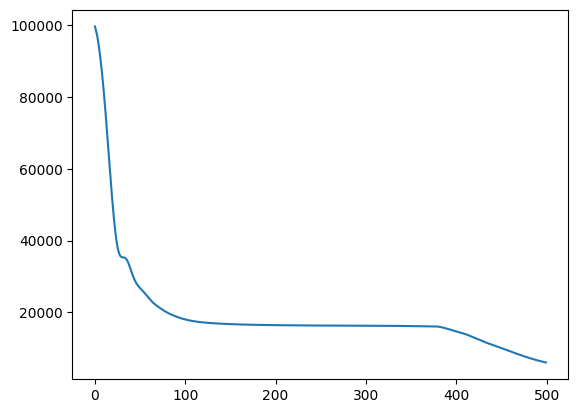

In [296]:
#Loss es la desviación entre Y_train y el Y_pred
loss_values = model_NN.loss_curve_
plt.plot(loss_values)

/tmp/ipykernel_6403/778866941.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


           Arbol        Knn                 NN
mse   416.425121  78.260870  35942.78927633502
rmse   20.406497   8.846517         189.585836
mae     8.405797   2.608696         135.974279
mape    0.043282   0.007051           0.814515
max    66.666667  30.000000         478.932179


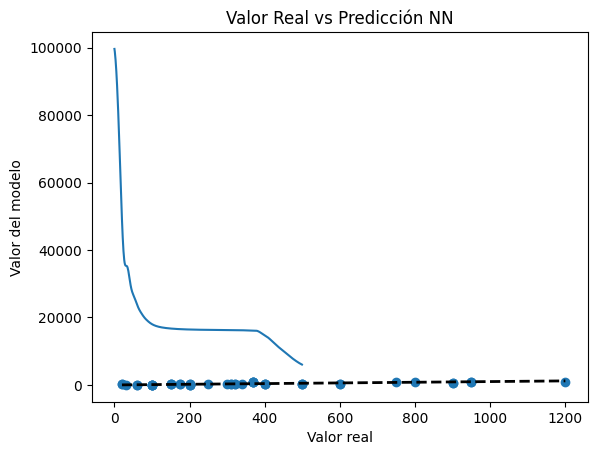

In [297]:
#Loss es la desviación entre Y_train y el Y_pred
loss_values = model_NN.loss_curve_
plt.plot(loss_values)

#Evaluación de NN
from sklearn import metrics

Y_pred = model_NN.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['NN']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción NN')
plt.show()


# SVM para Regresión - SVR

-Normalizar

In [298]:
#SVR
#Kernel='linear', 'poly', 'rbf', 'sigmoid', 'precomputed'

#SVM
from sklearn.svm import SVR

modelSVM = SVR(kernel='linear', degree=3) #'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
modelSVM.fit(X_train, Y_train) #70%

SVR(kernel='linear')

           Arbol        Knn                 NN                SVM
mse   416.425121  78.260870  35942.78927633502  87192.40761806339
rmse   20.406497   8.846517         189.585836         295.283605
mae     8.405797   2.608696         135.974279         206.853884
mape    0.043282   0.007051           0.814515           1.189396
max    66.666667  30.000000         478.932179         934.224653


/tmp/ipykernel_6403/2006006451.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


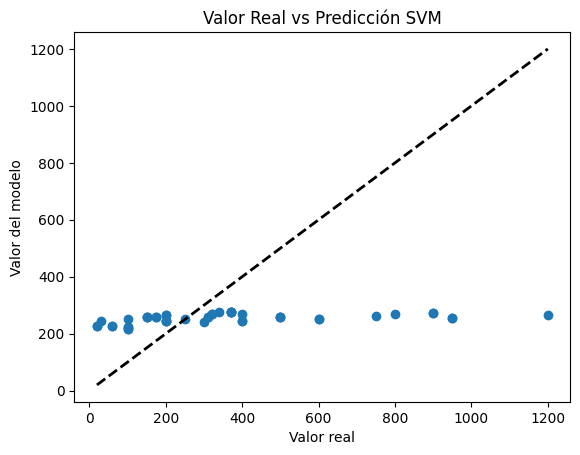

In [299]:
#Evaluación de SVM
from sklearn import metrics

Y_pred = modelSVM.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['SVM']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción SVM')
plt.show()

# Regresión Lineal
-Normalizar

In [300]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)

LinearRegression()

           Arbol        Knn                 NN                SVM  \
mse   416.425121  78.260870  35942.78927633502  87192.40761806339   
rmse   20.406497   8.846517         189.585836         295.283605   
mae     8.405797   2.608696         135.974279         206.853884   
mape    0.043282   0.007051           0.814515           1.189396   
max    66.666667  30.000000         478.932179         934.224653   

                     LR  
mse   51106.52411540365  
rmse         226.067521  
mae          183.100124  
mape             0.9159  
max          380.911766  


/tmp/ipykernel_6403/2449743100.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


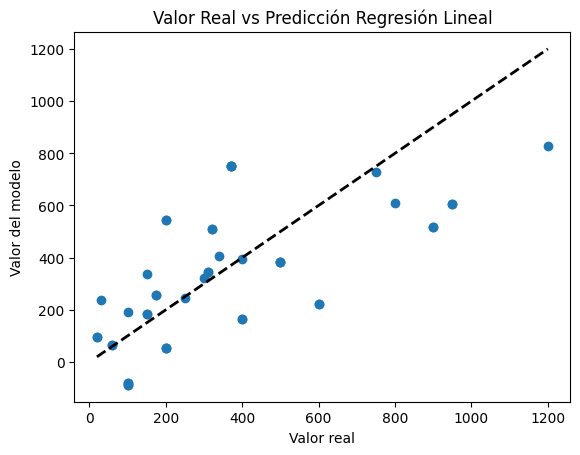

In [301]:
#Evaluación de RL
from sklearn import metrics

Y_pred = model_LR.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['LR']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Regresión Lineal')
plt.show()

In [302]:
print(medidas)


           Arbol        Knn                 NN                SVM  \
mse   416.425121  78.260870  35942.78927633502  87192.40761806339   
rmse   20.406497   8.846517         189.585836         295.283605   
mae     8.405797   2.608696         135.974279         206.853884   
mape    0.043282   0.007051           0.814515           1.189396   
max    66.666667  30.000000         478.932179         934.224653   

                     LR  
mse   51106.52411540365  
rmse         226.067521  
mae          183.100124  
mape             0.9159  
max          380.911766  


# 4. Guardamos el modelo seleccionado
Se entrena modelo final con 100% de los datos (X,Y)

In [303]:
#Normalizar X en caso de ser necesario: Knn, NN, SVM, Reg
X[variables_numericas]= min_max_scaler.transform(X[variables_numericas])

In [304]:
#Entrenamos modelo final
model_NN.fit(X, Y) #100%

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=2, learning_rate='adaptive',
             learning_rate_init=0.2, max_iter=500, momentum=0.4,
             random_state=3)

In [305]:
import pickle
filename = 'videojuegos-modelo-reg.pkl'
variables=X.columns._values
pickle.dump([model_NN, min_max_scaler,variables], open(filename, 'wb'))